<a href="https://colab.research.google.com/github/Zidane86-06/Data_Engineering_workshop/blob/main/Day2/Day2_Mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [3]:
df=pd.read_csv("student_performance.csv")
print(f"Dataset loaded:{df.shape[0]}students,{df.shape[1]}columns")
print(f"Columns:{df.columns}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:30students,13columns
Columns:Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [4]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Total students in the database:{count}")


Total students in the database:30


In [5]:
def run_query(sql, description="student"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql, conn)
  return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_quey(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_quey(sql_string, description_label)


In [6]:
query1=""" Select round(avg(programming_score),2) as avg_programming from students where gender="Female" group by gender"""
result1=run_query(query1, "Average programming scores for female students")
result1

Average programming scores for female students


,avg_programming
0,70.2


In [7]:
query2=""" Select department, round(avg(attendance_percentage),2) as "avg attendance" from students group by department having "avg attendance" > 85 order by avg(attendance_percentage) desc"""
result2=run_query(query2, "Average attendance percentage by department")
result2

Average attendance percentage by department


,department,avg attendance
0,Computer Science,90.69


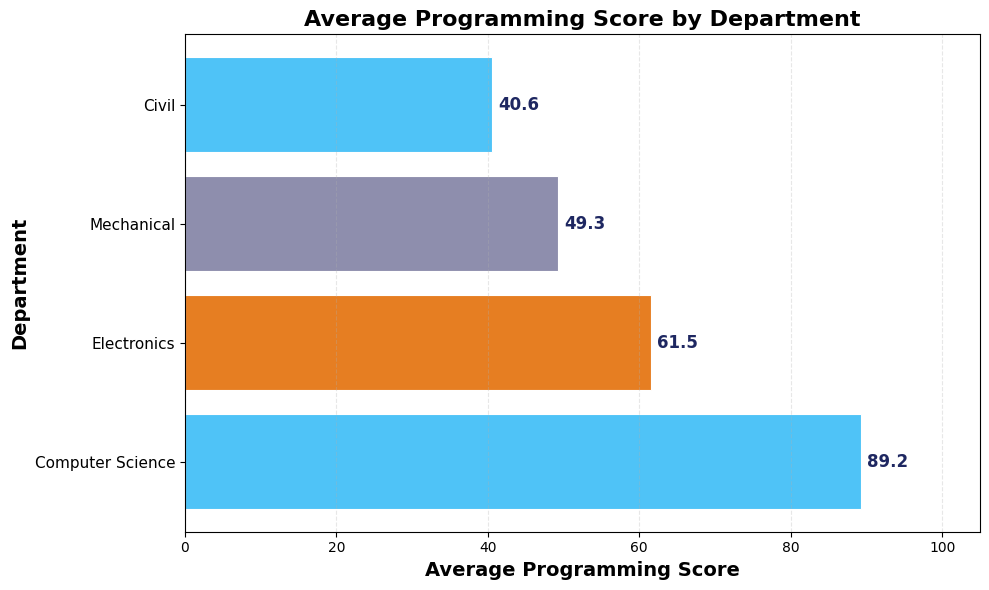

In [8]:
chart1_sql="""
select department,Round(AVG(programming_score),2) as avg_programming_score
from students
group by department
order by avg_programming_score desc
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=["#4FC3F7","#E67E22","#8E8EAD"]
bars=ax.barh(
    chart1_data["department"],
    chart1_data["avg_programming_score"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8)
for bar in bars:
  width=bar.get_width()
  ax.text(
      width+0.8,
      bar.get_y()+bar.get_height()/2,
      f'{width:.1f}', # Changed from % to just score
      ha='left',va='center',
      fontsize=12,fontweight='bold',
      color='#1E2761'
      )
  ax.set_title('Average Programming Score by Department',fontsize=16,fontweight='bold')
  ax.set_ylabel('Department',fontsize=14,fontweight='bold')
  ax.set_xlabel('Average Programming Score',fontsize=14,fontweight='bold')
  ax.set_xlim(0,105) # Keep 0-100 range for scores
  ax.tick_params(axis='y',labelsize=11)
  ax.grid(axis='x',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()

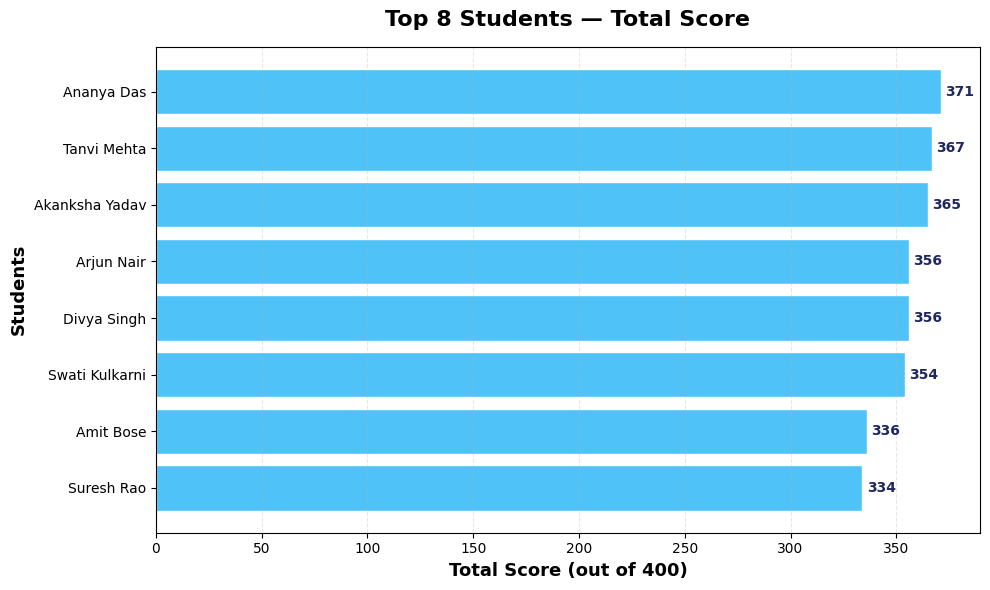

In [9]:
# SQL Query for Top 8 students
chart2_sql = """
SELECT
    name,
    (math_score + english_score + science_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

# Read SQL query
chart2_df = pd.read_sql_query(chart2_sql, conn)

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Horizontal bar chart
bars = ax.barh(
    chart2_df['name'],
    chart2_df['total_score'],
    color='#4FC3F7',
    edgecolor='white',
    linewidth=1
)

# Highest score at top
ax.invert_yaxis()

# Add score labels
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

# Titles and labels
ax.set_title(
    'Top 8 Students — Total Score',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Total Score (out of 400)',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    'Students',
    fontsize=13,
    fontweight='bold'
)

# Grid
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Layout
plt.tight_layout()

# Show plot
plt.show()

In [10]:
# =========================
# PANEL 1 → Avg Math by Department
# =========================
panel1_sql = """
SELECT
    department,
    ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

panel1_df = pd.read_sql_query(panel1_sql, conn)

print("Panel 1 Data: Average Math by Department")
print(panel1_df)

# =========================
# PANEL 2 → Student Count by Department
# =========================
panel2_sql = """
SELECT
    department,
    COUNT(*) AS student_count
FROM students
GROUP BY department
"""

panel2_df = pd.read_sql_query(panel2_sql, conn)

print("\nPanel 2 Data: Student Count by Department")
print(panel2_df)

# =========================
# PANEL 3 → Top 8 Students by Total Score
# =========================
panel3_sql = """
SELECT
    name,
    (math_score + english_score + science_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

panel3_df = pd.read_sql_query(panel3_sql, conn)

print("\nPanel 3 Data: Top 8 Students by Total Score")
print(panel3_df)

# =========================
# PANEL 4 → Gender-wise Average Attendance
# =========================
panel4_sql = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

panel4_df = pd.read_sql_query(panel4_sql, conn)

print("\nPanel 4 Data: Gender-wise Average Attendance")
print(panel4_df)

Panel 1 Data: Average Math by Department
         department  avg_math
0  Computer Science     85.62
1        Mechanical     71.00
2       Electronics     71.00
3             Civil     63.40

Panel 2 Data: Student Count by Department
         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6

Panel 3 Data: Top 8 Students by Total Score
             name  total_score
0      Ananya Das          371
1     Tanvi Mehta          367
2  Akanksha Yadav          365
3      Arjun Nair          356
4     Divya Singh          356
5  Swati Kulkarni          354
6       Amit Bose          336
7      Suresh Rao          334

Panel 4 Data: Gender-wise Average Attendance
   gender  avg_attendance
0  Female           88.53
1    Male           80.47


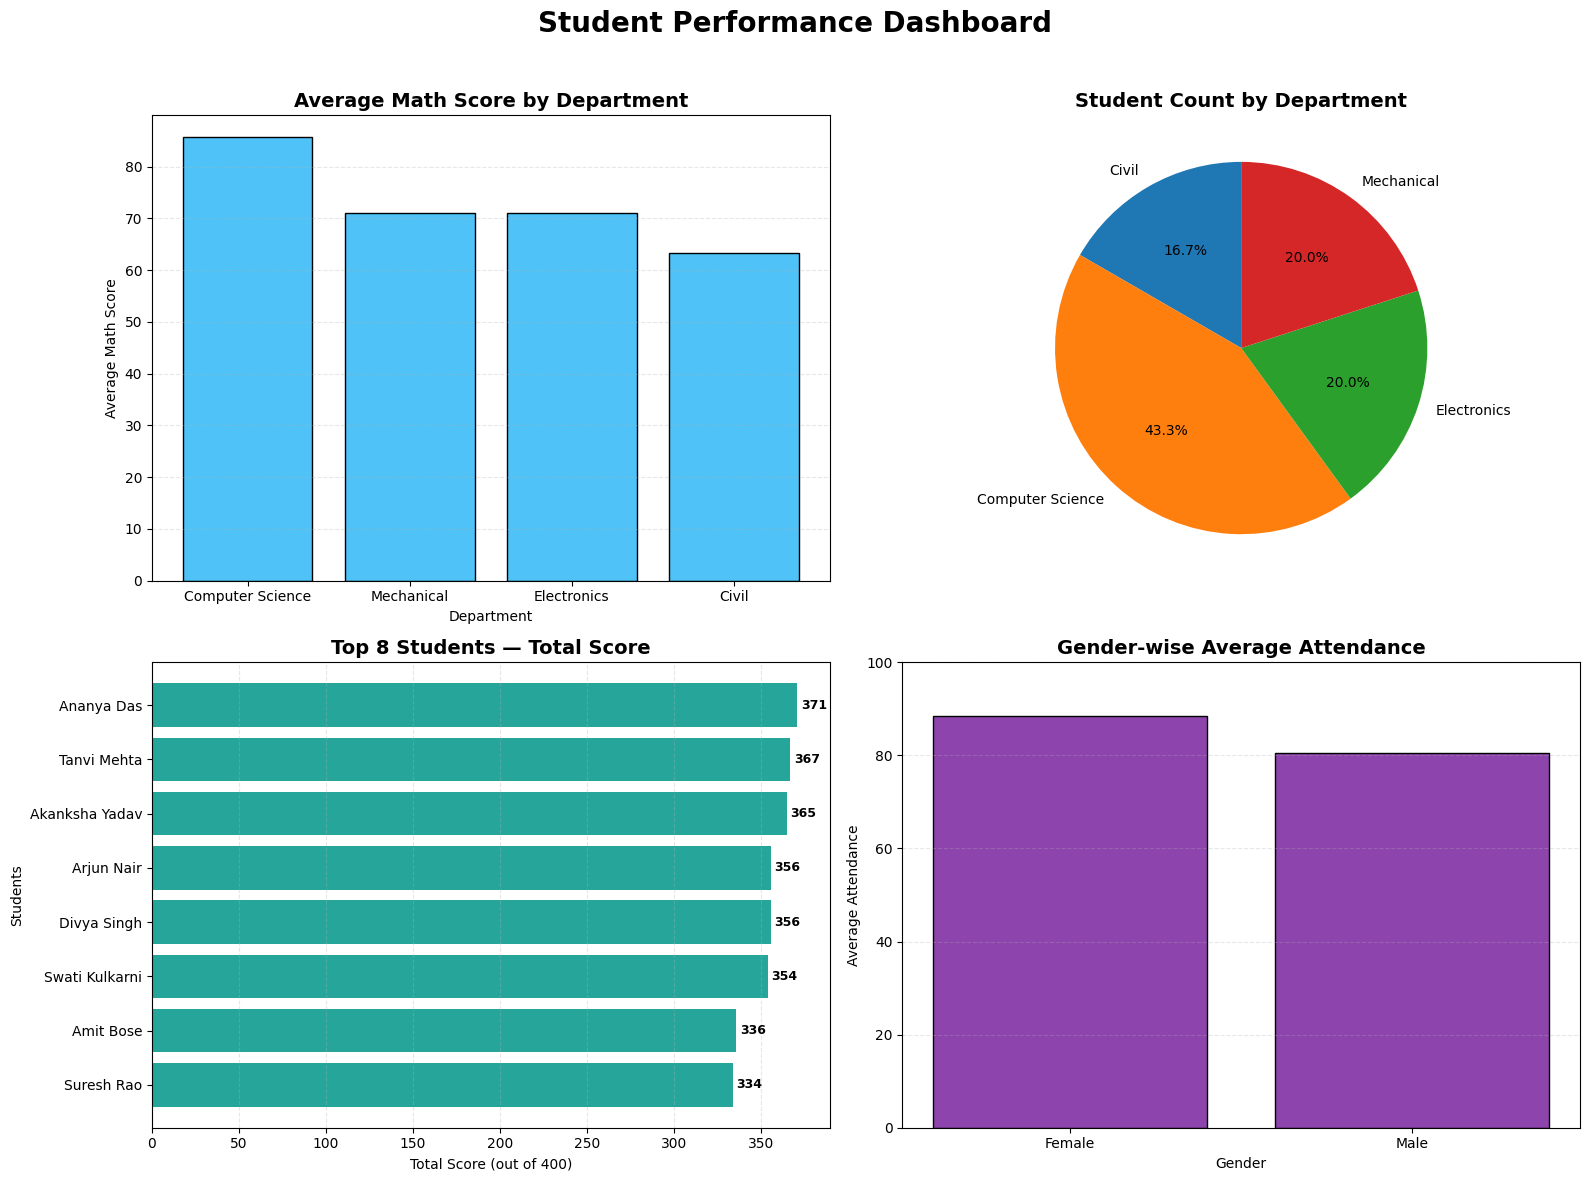

In [11]:
# =========================================================
# MATPLOTLIB DASHBOARD
# =========================================================

fig, axs = plt.subplots(2, 2, figsize=(16,12))

# =========================================================
# PANEL 1 (TOP-LEFT)
# Avg Math by Department → BAR CHART
# =========================================================
axs[0,0].bar(
    panel1_df['department'],
    panel1_df['avg_math'],
    color='#4FC3F7',
    edgecolor='black'
)

axs[0,0].set_title(
    'Average Math Score by Department',
    fontsize=14,
    fontweight='bold'
)

axs[0,0].set_xlabel('Department')
axs[0,0].set_ylabel('Average Math Score')

axs[0,0].grid(axis='y', linestyle='--', alpha=0.3)

# =========================================================
# PANEL 2 (TOP-RIGHT)
# Student Count → PIE CHART
# =========================================================
axs[0,1].pie(
    panel2_df['student_count'],
    labels=panel2_df['department'],
    autopct='%1.1f%%',
    startangle=90
)

axs[0,1].set_title(
    'Student Count by Department',
    fontsize=14,
    fontweight='bold'
)

# =========================================================
# PANEL 3 (BOTTOM-LEFT)
# Top 8 Students → HORIZONTAL BAR CHART
# =========================================================
bars = axs[1,0].barh(
    panel3_df['name'],
    panel3_df['total_score'],
    color='#26A69A'
)

axs[1,0].invert_yaxis()

axs[1,0].set_title(
    'Top 8 Students — Total Score',
    fontsize=14,
    fontweight='bold'
)

axs[1,0].set_xlabel('Total Score (out of 400)')
axs[1,0].set_ylabel('Students')

axs[1,0].grid(axis='x', linestyle='--', alpha=0.3)

# Add labels
for bar in bars:
    width = bar.get_width()

    axs[1,0].text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# =========================================================
# PANEL 4 (BOTTOM-RIGHT)
# Gender Avg Attendance → BAR CHART
# =========================================================
axs[1,1].bar(
    panel4_df['gender'],
    panel4_df['avg_attendance'],
    color='#8E44AD',
    edgecolor='black'
)

axs[1,1].set_title(
    'Gender-wise Average Attendance',
    fontsize=14,
    fontweight='bold'
)

axs[1,1].set_xlabel('Gender')
axs[1,1].set_ylabel('Average Attendance')

axs[1,1].set_ylim(0,100)

axs[1,1].grid(axis='y', linestyle='--', alpha=0.3)

# =========================================================
# MAIN TITLE
# =========================================================
fig.suptitle(
    'Student Performance Dashboard',
    fontsize=20,
    fontweight='bold'
)

# Adjust spacing
plt.tight_layout(rect=[0,0,1,0.96])

# Show Dashboard
plt.show()